In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

DATA_PATH = "/content/drive/MyDrive/gridlock_flipkart/enriched_violations.csv"   # update path if running on Colab Drive
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} records, {df.shape[1]} columns")
df.head(3)

Loaded 115,400 records, 24 columns


,id,latitude,longitude,police_station,junction_name,junction_code,at_junction,created_dt,date,hour,...,time_bin,is_weekend,violation_type,violations_list,violation_count,severity_score,is_parking_related,vehicle_type,vehicle_weight,validation_status
0,FKID000000,12.925557,77.618665,Madiwala,No Junction,NaN,0,2023-11-20 00:28:46+00:00,2023-11-20,0,...,night,0,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']",2,3,1,CAR,1.0,approved
1,FKID000002,12.925449,77.618504,Madiwala,No Junction,NaN,0,2023-11-20 00:27:46+00:00,2023-11-20,0,...,night,0,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","['WRONG PARKING', 'PARKING IN A MAIN ROAD']",2,4,1,CAR,1.0,approved
2,FKID000003,12.956521,77.518618,Byatarayanapura,No Junction,NaN,0,2023-11-16 06:47:46+00:00,2023-11-16,6,...,morning,0,"[""NO PARKING""]",['NO PARKING'],1,2,1,SCOOTER,0.4,approved


## 1. Pre-clustering adjustments

**Correction from EDA review:** 24.27% coordinate duplication is not "clean data" —
it likely reflects fixed enforcement cameras or single-officer posts issuing many
challans from the exact same GPS point. Left unchecked, HDBSCAN will treat these
as artificially dense micro-hotspots.

**Fix:** flag (not remove) points repeating beyond a threshold, so we can later
distinguish *camera-artifact density* from *organic spatial density* per cluster.


In [5]:
# Identify repeated coordinates
coord_counts = (
    df.groupby(["latitude", "longitude"])
      .size()
      .reset_index(name="point_repeat_count")
)

df = df.merge(coord_counts, on=["latitude", "longitude"], how="left")

REPEAT_THRESHOLD = 10   # points repeating more than this = likely fixed camera/post
df["is_repeated_point"] = (df["point_repeat_count"] > REPEAT_THRESHOLD).astype(int)

print(f"Points flagged as repeated (>{REPEAT_THRESHOLD}x): "
      f"{df['is_repeated_point'].sum():,} records "
      f"({df['is_repeated_point'].mean()*100:.1f}%)")
print(f"Unique repeated coordinate locations: "
      f"{(coord_counts['point_repeat_count'] > REPEAT_THRESHOLD).sum()}")

coord_counts.sort_values('point_repeat_count', ascending=False).head(10)

Points flagged as repeated (>10x): 1,422 records (1.2%)
Unique repeated coordinate locations: 94


,latitude,longitude,point_repeat_count
8064,12.930011,77.685171,46
10392,12.934068,77.689769,36
81314,13.034841,77.557343,31
10511,12.934368,77.690132,27
6921,12.926678,77.677832,27
10540,12.934467,77.690405,26
61259,12.987962,77.734140,24
153,12.839274,77.677801,23
71254,13.001045,77.549760,21
1666,12.891687,77.638497,21


5th nearest-neighbor distance (degrees):
count    115400.000000
mean          0.000121
std           0.000458
min           0.000000
25%           0.000016
50%           0.000037
75%           0.000087
max           0.029828
dtype: float64

~4m corresponds to roughly 0.00004 degrees at this latitude
This anchors our min_samples / min_cluster_size search range below


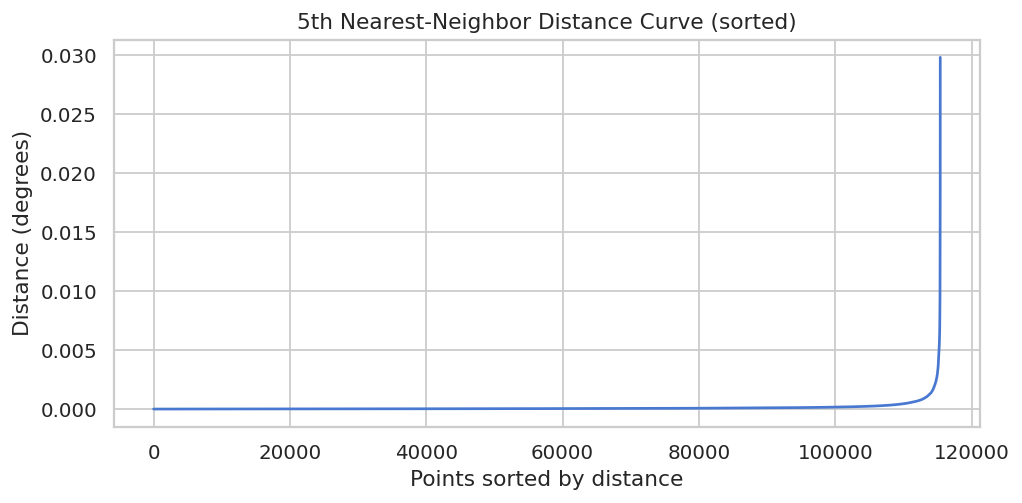

In [6]:
# K-NN distance check (carried forward from EDA — confirms eps/min_samples range)
coords = df[["latitude", "longitude"]].values
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(coords)
distances, _ = nbrs.kneighbors(coords)
kdist = np.sort(distances[:, 4])

print("5th nearest-neighbor distance (degrees):")
print(pd.Series(kdist).describe())
print(f"\n~4m corresponds to roughly 0.00004 degrees at this latitude")
print(f"This anchors our min_samples / min_cluster_size search range below")

plt.figure(figsize=(8, 4))
plt.plot(kdist)
plt.title("5th Nearest-Neighbor Distance Curve (sorted)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance (degrees)")
plt.grid(True)
plt.tight_layout()
plt.savefig("s2_knn_distance.png")
plt.show()

In [7]:
min_cluster_sizes = [50, 100, 200, 500, 800, 1200, 1800, 2500, 3500]
min_samples_list  = [10, 20, 50]

X = df[["latitude", "longitude"]].values

sweep_results = []

for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric="euclidean",
            core_dist_n_jobs=-1
        )
        labels = clusterer.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct  = (labels == -1).mean() * 100

        if n_clusters > 0:
            sizes = pd.Series(labels[labels != -1]).value_counts()
            largest_cluster = sizes.max()
            median_cluster  = sizes.median()
        else:
            largest_cluster = 0
            median_cluster  = 0

        sweep_results.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "num_clusters": n_clusters,
            "noise_pct": round(noise_pct, 1),
            "largest_cluster_size": largest_cluster,
            "median_cluster_size": median_cluster
        })

        print(f"mcs={mcs:>4} ms={ms:>3} → clusters={n_clusters:>3}  "
              f"noise={noise_pct:>5.1f}%  largest={largest_cluster:>6}  "
              f"median={median_cluster:>6.0f}")

sweep_df = pd.DataFrame(sweep_results)

mcs=  50 ms= 10 → clusters=523  noise= 18.7%  largest=  1758  median=   113
mcs=  50 ms= 20 → clusters=449  noise= 17.7%  largest=  2903  median=   120
mcs=  50 ms= 50 → clusters=377  noise= 22.3%  largest=  2890  median=   139
mcs= 100 ms= 10 → clusters=297  noise= 16.6%  largest=  3143  median=   217
mcs= 100 ms= 20 → clusters=277  noise= 18.1%  largest=  3108  median=   237
mcs= 100 ms= 50 → clusters=242  noise= 20.1%  largest=  2890  median=   258
mcs= 200 ms= 10 → clusters=181  noise= 17.4%  largest=  3143  median=   429
mcs= 200 ms= 20 → clusters=170  noise= 18.3%  largest=  3108  median=   429
mcs= 200 ms= 50 → clusters=158  noise= 20.6%  largest=  2890  median=   446
mcs= 500 ms= 10 → clusters= 87  noise= 23.1%  largest=  3659  median=   817
mcs= 500 ms= 20 → clusters= 80  noise= 21.0%  largest=  4149  median=   898
mcs= 500 ms= 50 → clusters= 77  noise= 24.8%  largest=  2921  median=   935
mcs= 800 ms= 10 → clusters= 46  noise= 26.2%  largest=  6736  median=  1690
mcs= 800 ms=

In [8]:
# Comparison table sorted to highlight the 10-30 cluster sweet spot
sweep_df["in_target_range"] = sweep_df["num_clusters"].between(10, 30)
sweep_df["largest_to_median_ratio"] = (
    sweep_df["largest_cluster_size"] / sweep_df["median_cluster_size"]
).round(1)
sweep_df_sorted = sweep_df.sort_values(
    ["in_target_range", "noise_pct"], ascending=[False, True]
)
sweep_df_sorted

# A high largest_to_median_ratio (>5x) signals a likely mega-cluster merging
# multiple distinct hotspots — prefer combinations below that, even if it
# means landing at the upper edge of the target range rather than the lower

,min_cluster_size,min_samples,num_clusters,noise_pct,largest_cluster_size,median_cluster_size,in_target_range,largest_to_median_ratio
19,1800,20,22,25.2,25675,2673.0,True,9.6
15,1200,10,30,25.4,8292,2313.0,True,3.6
26,3500,50,10,28.0,18048,5636.0,True,3.2
22,2500,20,12,29.0,25675,4348.5,True,5.9
23,2500,50,14,32.2,13567,4021.5,True,3.4
18,1800,10,23,33.3,8292,3267.0,True,2.5
20,1800,50,19,34.0,12140,3604.0,True,3.4
21,2500,10,13,35.8,12811,4147.0,True,3.1
3,100,10,297,16.6,3143,217.0,False,14.5
6,200,10,181,17.4,3143,429.0,False,7.3


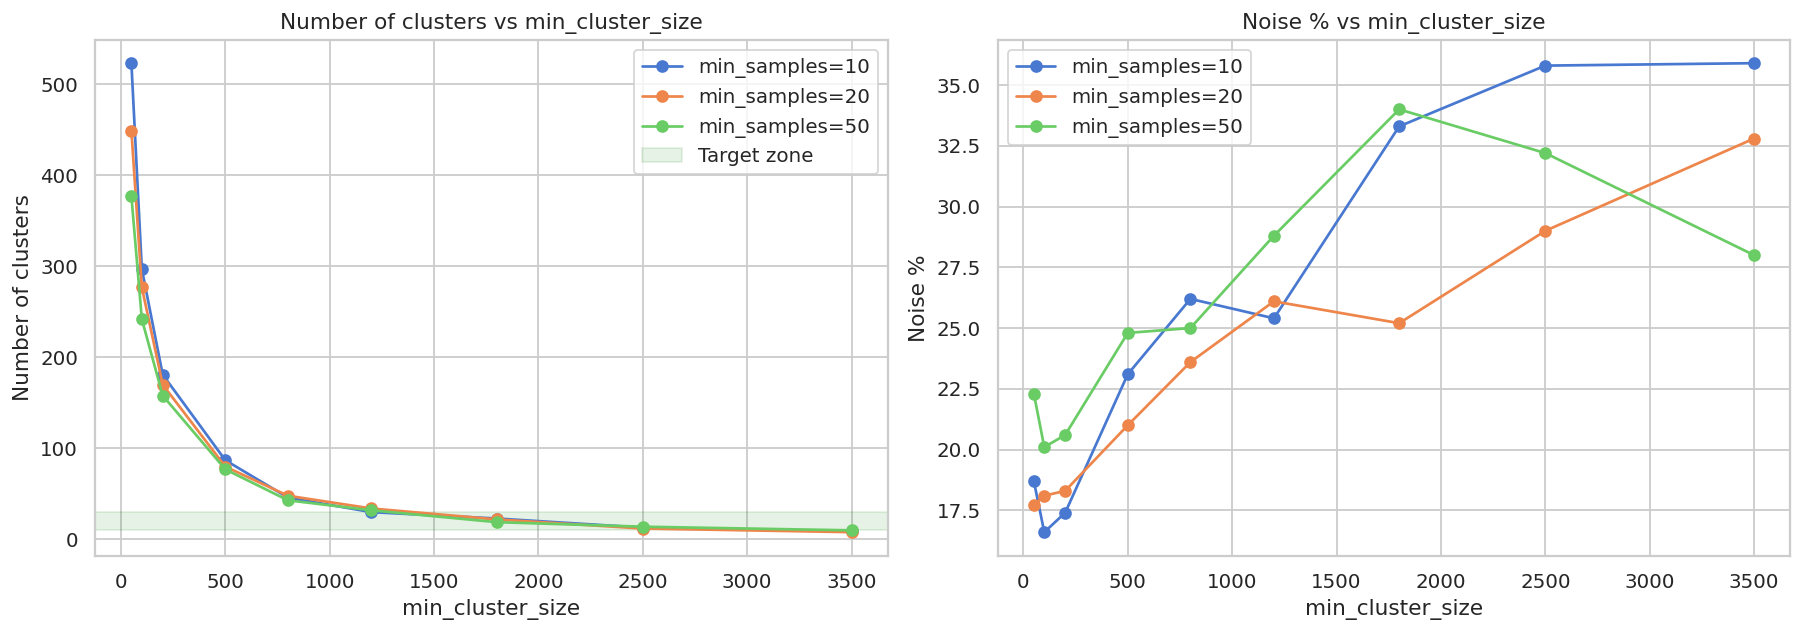

In [9]:
# Visualize the tradeoff: cluster count vs noise % across the grid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ms in min_samples_list:
    sub = sweep_df[sweep_df["min_samples"] == ms]
    axes[0].plot(sub["min_cluster_size"], sub["num_clusters"],
                 marker="o", label=f"min_samples={ms}")
    axes[1].plot(sub["min_cluster_size"], sub["noise_pct"],
                 marker="o", label=f"min_samples={ms}")

axes[0].axhspan(10, 30, color="green", alpha=0.1, label="Target zone")
axes[0].set_title("Number of clusters vs min_cluster_size")
axes[0].set_xlabel("min_cluster_size")
axes[0].set_ylabel("Number of clusters")
axes[0].legend()

axes[1].set_title("Noise % vs min_cluster_size")
axes[1].set_xlabel("min_cluster_size")
axes[1].set_ylabel("Noise %")
axes[1].legend()

plt.tight_layout()
plt.savefig("s2_param_sweep.png")
plt.show()

## 3. Final clustering

**Chosen parameters: `min_cluster_size=1200, min_samples=10`**

From the sweep table: this combination lands at exactly 30 clusters (top edge of
the 10–30 target zone) with 25.4% noise. It was preferred over nearby alternatives
(`mcs=1800, ms=20` → 22 clusters) because that alternative produces one 25,675-point
mega-cluster — 10x the median cluster size — which almost certainly merges several
distinct hotspots into one. At `mcs=1200, ms=10`, the largest cluster (8,293) is only
3.6x the median (2,312), meaning no single cluster is swallowing the others. This is
the more operationally meaningful split: 30 distinguishable zones rather than a
handful of oversized regions a patrol commander can't act on.


In [10]:
FINAL_MCS = 1200   # min_cluster_size
FINAL_MS  = 10     # min_samples

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=FINAL_MCS,
    min_samples=FINAL_MS,
    metric="euclidean",
    core_dist_n_jobs=-1
)
df["cluster_id"] = clusterer.fit_predict(X)
df["cluster_probability"] = clusterer.probabilities_

n_clusters = len(set(df["cluster_id"])) - (1 if -1 in df["cluster_id"].values else 0)
noise_pct  = (df["cluster_id"] == -1).mean() * 100

print(f"Final clustering: min_cluster_size={FINAL_MCS}, min_samples={FINAL_MS}")
print(f"Number of clusters : {n_clusters}")
print(f"Noise points        : {(df['cluster_id']==-1).sum():,} ({noise_pct:.1f}%)")

Final clustering: min_cluster_size=1200, min_samples=10
Number of clusters : 30
Noise points        : 29,327 (25.4%)


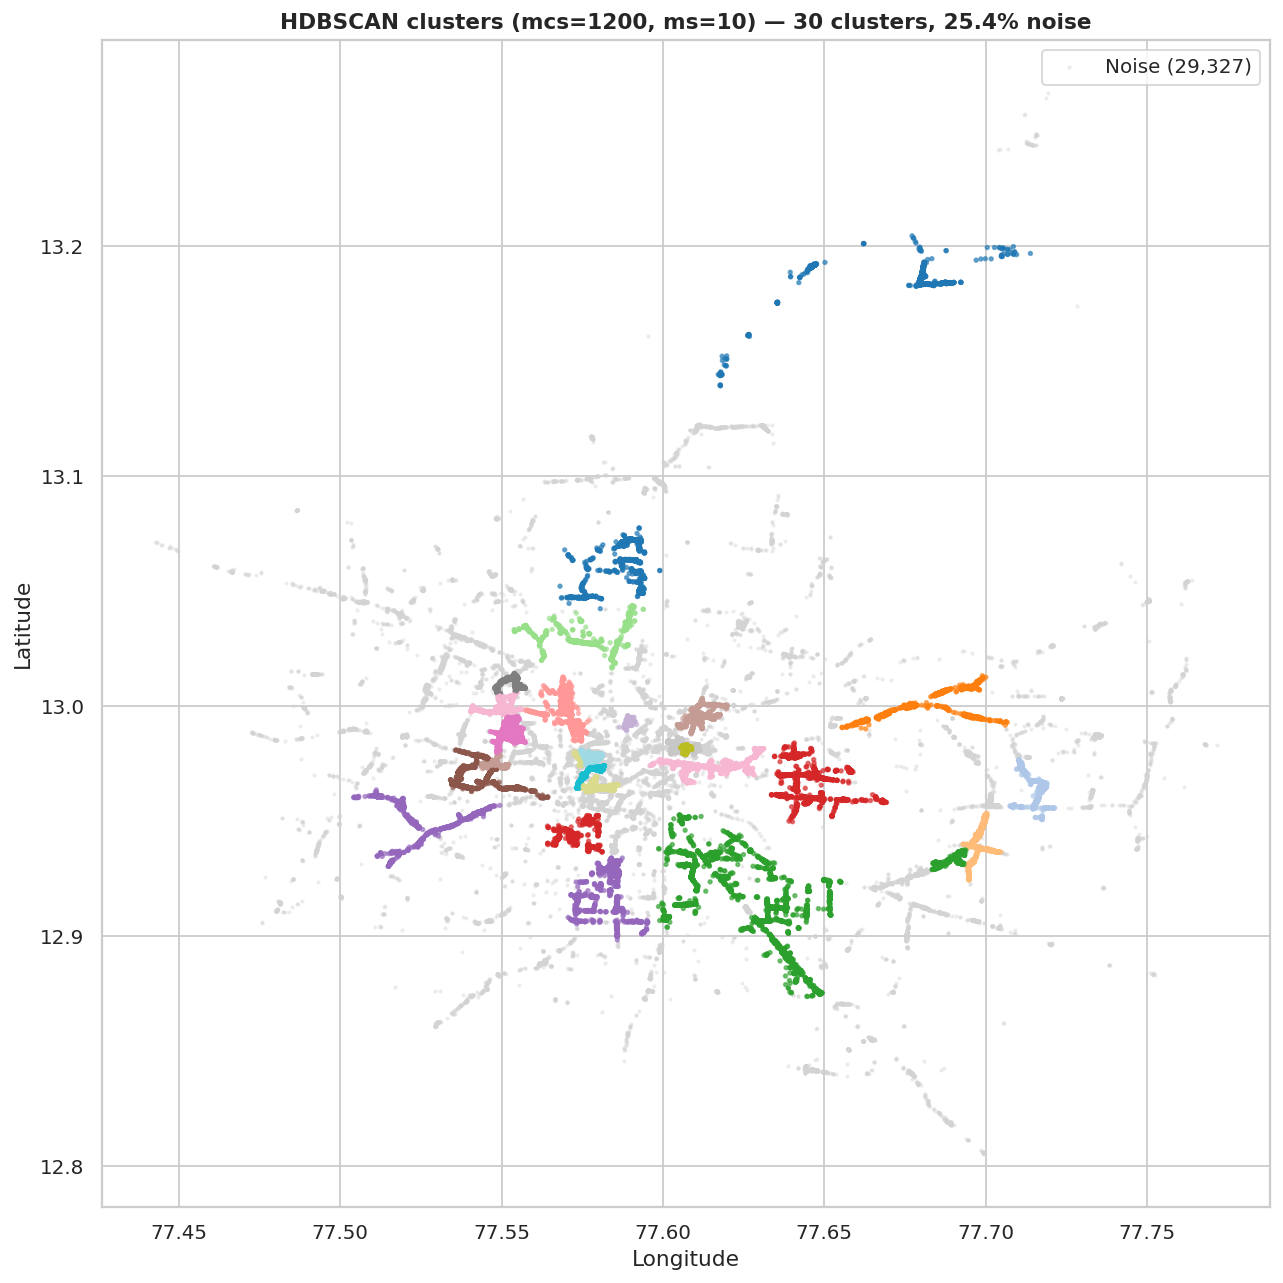

In [11]:
# Visual sanity check — plot clusters on lat/lon
fig, ax = plt.subplots(figsize=(10, 10))

noise = df[df["cluster_id"] == -1]
ax.scatter(noise["longitude"], noise["latitude"],
           s=2, c="lightgray", alpha=0.3, label=f"Noise ({len(noise):,})")

clustered = df[df["cluster_id"] != -1]
scatter = ax.scatter(clustered["longitude"], clustered["latitude"],
                      s=4, c=clustered["cluster_id"], cmap="tab20", alpha=0.6)

ax.set_title(f"HDBSCAN clusters (mcs={FINAL_MCS}, ms={FINAL_MS}) — "
             f"{n_clusters} clusters, {noise_pct:.1f}% noise", fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("s2_final_clusters_map.png")
plt.show()

## 4. Per-cluster summary table

This table is the single most important output of Stage 2 — it becomes the
input to every downstream stage (persistence analysis, isolation forest,
OSMnx exposure, impact index, priority ranking).


In [12]:
cluster_summary = (
    df[df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(
        size                 = ("id", "count"),
        centroid_lat         = ("latitude", "mean"),
        centroid_lon         = ("longitude", "mean"),
        avg_severity         = ("severity_score", "mean"),
        avg_vehicle_weight   = ("vehicle_weight", "mean"),
        junction_ratio       = ("at_junction", "mean"),
        repeated_point_ratio = ("is_repeated_point", "mean"),
        avg_cluster_prob     = ("cluster_probability", "mean"),
        multi_violation_pct  = ("violation_count", lambda x: (x > 1).mean()),
    )
    .reset_index()
    .sort_values("size", ascending=False)
)

# Top police station per cluster
top_station = (
    df[df["cluster_id"] != -1]
    .groupby(["cluster_id", "police_station"])
    .size()
    .reset_index(name="n")
    .sort_values(["cluster_id", "n"], ascending=[True, False])
    .groupby("cluster_id")
    .first()[["police_station", "n"]]
    .rename(columns={"police_station": "top_station", "n": "top_station_count"})
    .reset_index()
)

cluster_summary = cluster_summary.merge(top_station, on="cluster_id")
cluster_summary["top_station_pct"] = (
    cluster_summary["top_station_count"] / cluster_summary["size"]
)

cluster_summary = cluster_summary.drop(columns=["top_station_count"])
cluster_summary

,cluster_id,size,centroid_lat,centroid_lon,avg_severity,avg_vehicle_weight,junction_ratio,repeated_point_ratio,avg_cluster_prob,multi_violation_pct,top_station,top_station_pct
0,29,8292,12.977098,77.576941,2.028341,0.700832,0.998070,0.012301,0.757619,0.040762,Upparpet,0.999759
1,7,5264,12.915963,77.625859,2.182181,0.797169,0.293693,0.019757,0.931220,0.110562,HSR Layout,0.341565
2,25,4879,12.964669,77.578713,2.076860,0.650318,0.992416,0.002869,0.668112,0.059643,City Market,0.659561
3,11,4338,13.000357,77.570468,2.013601,0.784693,0.005071,0.012218,0.704725,0.016367,Malleshwaram,0.790226
4,27,4087,12.971175,77.577458,2.132860,0.637240,0.904575,0.025691,0.830219,0.097627,Upparpet,0.496452
5,20,4068,12.999515,77.549452,2.016224,0.660275,1.000000,0.009833,0.707981,0.021386,Malleshwaram,0.468781
6,24,3603,12.981261,77.607574,2.042742,0.585679,1.000000,0.025534,0.837902,0.072717,Shivajinagar,1.000000
7,21,3436,13.010036,77.553407,2.006694,0.764115,0.456345,0.007858,0.946467,0.022992,Malleshwaram,0.884459
8,6,3386,12.933235,77.690060,2.508269,0.617395,0.000000,0.085056,0.556483,0.357649,HAL Old Airport,1.000000
9,9,3311,12.967537,77.648129,2.273029,0.762126,0.143763,0.000000,0.964305,0.240109,Jeevanbheemanagar,0.918454


In [13]:
# Flag clusters that are mostly artifact (camera/post-driven) vs organic
ARTIFACT_THRESHOLD = 0.5  # if >50% of cluster's points are repeated-coordinate points

cluster_summary["likely_camera_artifact"] = (
    cluster_summary["repeated_point_ratio"] > ARTIFACT_THRESHOLD
)

print(f"Clusters flagged as likely camera/post artifact: "
      f"{cluster_summary['likely_camera_artifact'].sum()} / {len(cluster_summary)}")

cluster_summary[cluster_summary["likely_camera_artifact"]][
    ["cluster_id", "size", "repeated_point_ratio", "top_station"]
]

Clusters flagged as likely camera/post artifact: 0 / 30


,cluster_id,size,repeated_point_ratio,top_station


In [14]:
print("="*60)
print("STAGE 2 SUCCESS CRITERIA CHECK")
print("="*60)

print(f"\n1. How many hotspots exist?")
print(f"   → {n_clusters} clusters detected")

print(f"\n2. What % of records are noise?")
print(f"   → {noise_pct:.1f}%")

largest = cluster_summary.loc[cluster_summary["size"].idxmax()]
print(f"\n3. Which hotspot is largest?")
print(f"   → Cluster {int(largest['cluster_id'])}: {int(largest['size']):,} violations "
      f"near {largest['top_station']}")

most_severe = cluster_summary.loc[cluster_summary["avg_severity"].idxmax()]
print(f"\n4. Which hotspot is most severe?")
print(f"   → Cluster {int(most_severe['cluster_id'])}: "
      f"avg severity {most_severe['avg_severity']:.2f} near {most_severe['top_station']}")

print(f"\n5. Which police stations dominate each hotspot?")
print(cluster_summary[["cluster_id","top_station","top_station_pct"]]
      .head(10).to_string(index=False))

print("\n" + "="*60)
print("All five questions answerable → Stage 2 criteria met")
print("="*60)

STAGE 2 SUCCESS CRITERIA CHECK

1. How many hotspots exist?
   → 30 clusters detected

2. What % of records are noise?
   → 25.4%

3. Which hotspot is largest?
   → Cluster 29: 8,292 violations near Upparpet

4. Which hotspot is most severe?
   → Cluster 5: avg severity 3.04 near HAL Old Airport

5. Which police stations dominate each hotspot?
 cluster_id       top_station  top_station_pct
         29          Upparpet         0.999759
          7        HSR Layout         0.341565
         25       City Market         0.659561
         11      Malleshwaram         0.790226
         27          Upparpet         0.496452
         20      Malleshwaram         0.468781
         24      Shivajinagar         1.000000
         21      Malleshwaram         0.884459
          6   HAL Old Airport         1.000000
          9 Jeevanbheemanagar         0.918454

All five questions answerable → Stage 2 criteria met
